In [39]:
import numpy as np 
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import statsmodels.tsa.stattools as sm
%matplotlib inline

# In sample 

In [40]:
TIME = "10y"
START = "2014-01-01"
END = "2025-01-01"
PRICE = "Close"
THRESHOLD = 2
T_MAX = 500
TRANSACTION_PRICE = 0.05

A_stock = "V"
B_stock = "MA" 



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


2768 2768


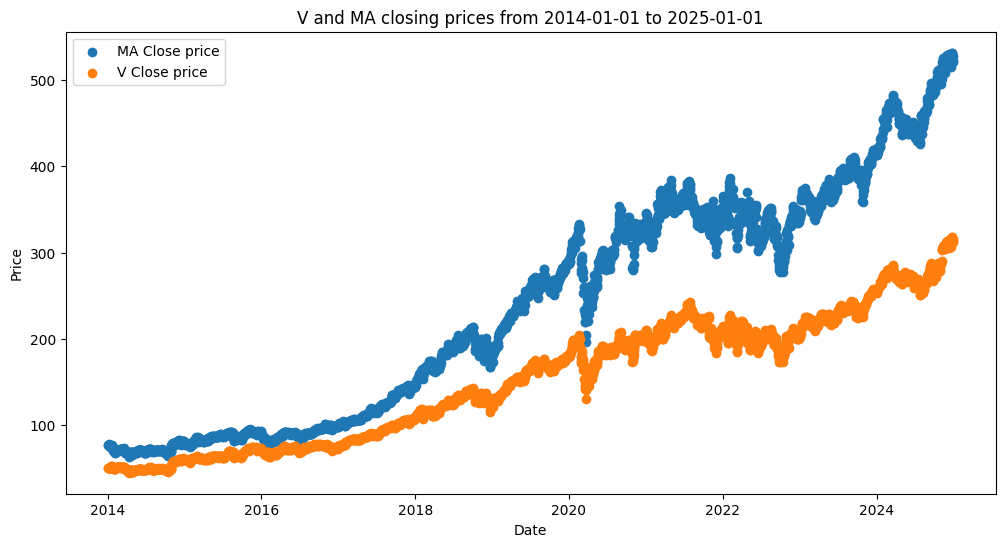

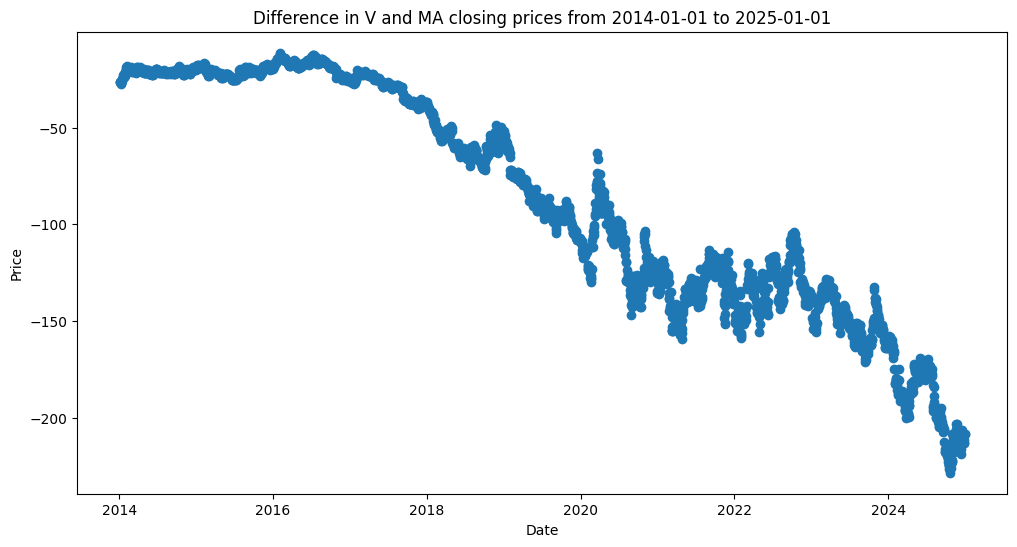

(2768, 1)

In [41]:
B_data = yf.download(B_stock, start=START, end=END)
A_data = yf.download(A_stock, start=START, end=END)

if A_data[PRICE].values.flatten().mean() > B_data[PRICE].values.flatten().mean():
    temp = A_data
    A_data = B_data
    B_data = temp

print(len(B_data.index), len(A_data.index))
time_data = B_data.index

plt.figure(figsize=(12, 6))
plt.scatter(time_data, B_data[PRICE], label=f"{B_stock} {PRICE} price")
plt.scatter(time_data, A_data[PRICE], label=f"{A_stock} {PRICE} price")
plt.title(f"{A_stock} and {B_stock} closing prices from {START} to {END}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(time_data, (A_data[PRICE].values.flatten() - B_data[PRICE].values.flatten()), label="Difference")
plt.title(f"Difference in {A_stock} and {B_stock} closing prices from {START} to {END}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

B_data[PRICE].shape

## Coint tests

In [42]:
_, p_value, _ = sm.coint(B_data[PRICE].values.flatten(), A_data[PRICE].values.flatten())
print(f"Cointegration p-value: {p_value:.4f}")

Cointegration p-value: 0.0006


## Trading

In [43]:
params = np.polyfit(B_data[PRICE].values.flatten(), A_data[PRICE].values.flatten(), deg=1)

print(params)

[ 0.55242188 20.23761535]


[]

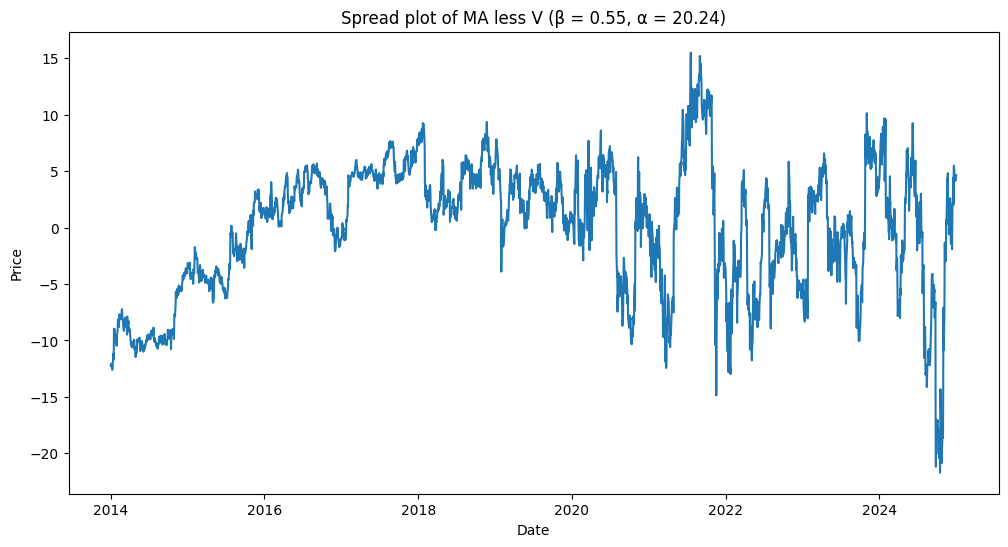

In [44]:
spread = A_data[PRICE].values.flatten() - params[0]*B_data[PRICE].values.flatten() - params[1]

plt.figure(figsize=(12, 6))
plt.plot(time_data, spread, label="Spread")
plt.title(f"Spread plot of {B_stock} less {A_stock} (\u03B2 = {round(params[0], 2)}, \u03b1 = {round(params[1], 2)})")
plt.xlabel("Date")
plt.ylabel("Price")
plt.plot()

1.1623329145671003e-14 5.770996318571079


[]

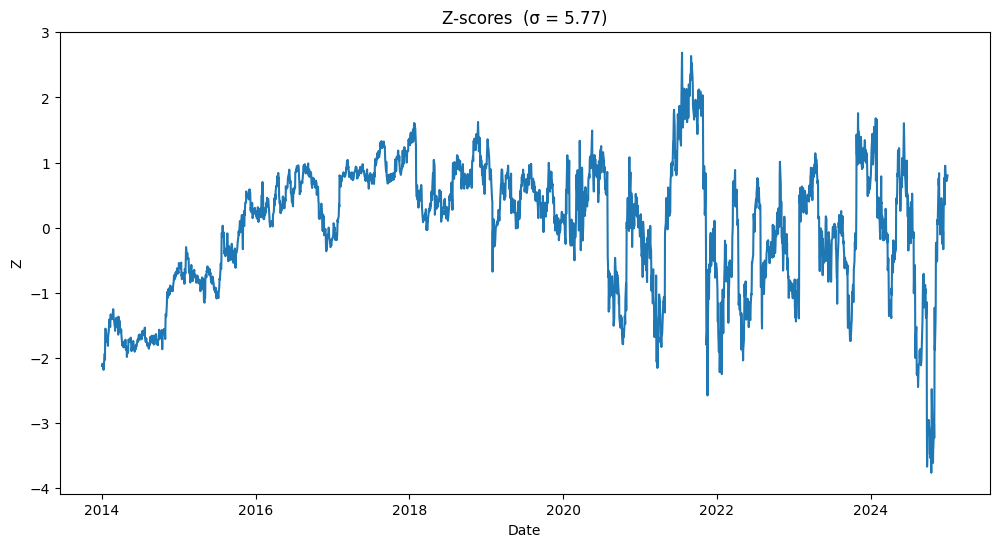

In [45]:
print(np.mean(spread), np.std(spread))

sigma = np.std(spread)

z_scores = spread / sigma

plt.figure(figsize=(12, 6))
plt.plot(time_data, z_scores, label="Spread")
plt.title(f"Z-scores  (\u03C3 = {round(sigma, 2)})")
plt.xlabel("Date")
plt.ylabel("Z")
plt.plot()

In [46]:
def signal(z, threshold):
    if z > threshold: return -1 # Short the spread
    elif z < -threshold: return 1 # Long the spread
    return 0 # Flat

signals = list(map(lambda z: signal(z, threshold=THRESHOLD), z_scores))

# plt.figure(figsize=(12, 6))
# plt.plot(time_data, z_scores, label="Z scores")
# plt.title(f"Z-scores  (\u03C3 = {round(sigma, 2)})")
# plt.xlabel("Date")
# plt.ylabel("Z")
# plt.plot()


[]

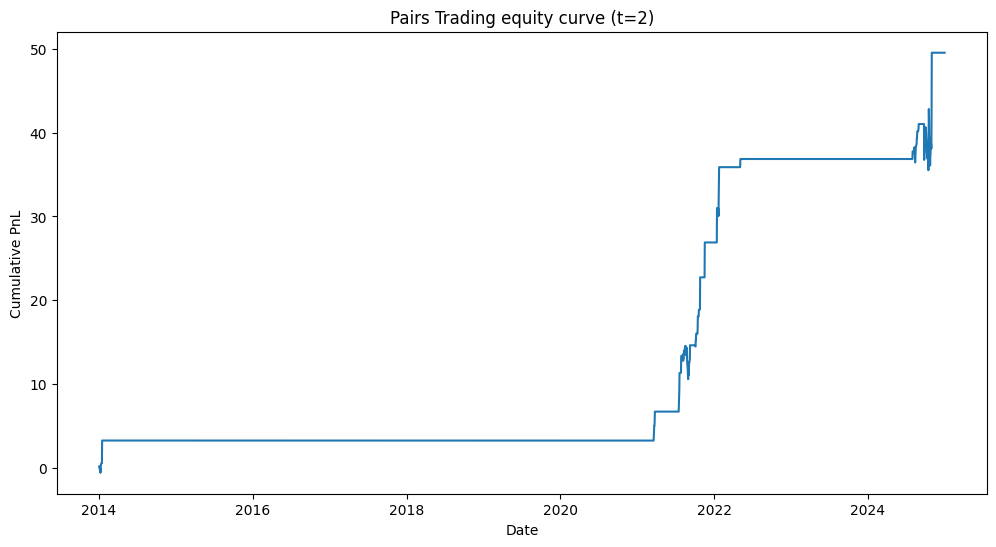

In [47]:
PnL = signals[:-1] * np.diff(spread) - (np.abs(signals[:-1])*TRANSACTION_PRICE)

plt.figure(figsize=(12, 6))
plt.plot(time_data[:-1], np.cumsum(PnL))
plt.title(f"Pairs Trading equity curve (t={THRESHOLD})")
plt.ylabel("Cumulative PnL")
plt.xlabel("Date")
plt.plot()


In [48]:
print(np.mean(PnL) / np.std(PnL) * np.sqrt(252))

0.8637800383302243


/tmp/ipykernel_82333/3264418898.py:8: RuntimeWarning: invalid value encountered in scalar divide
  sharpes.append(np.mean(PnL) / np.std(PnL) * np.sqrt(252))


3.77


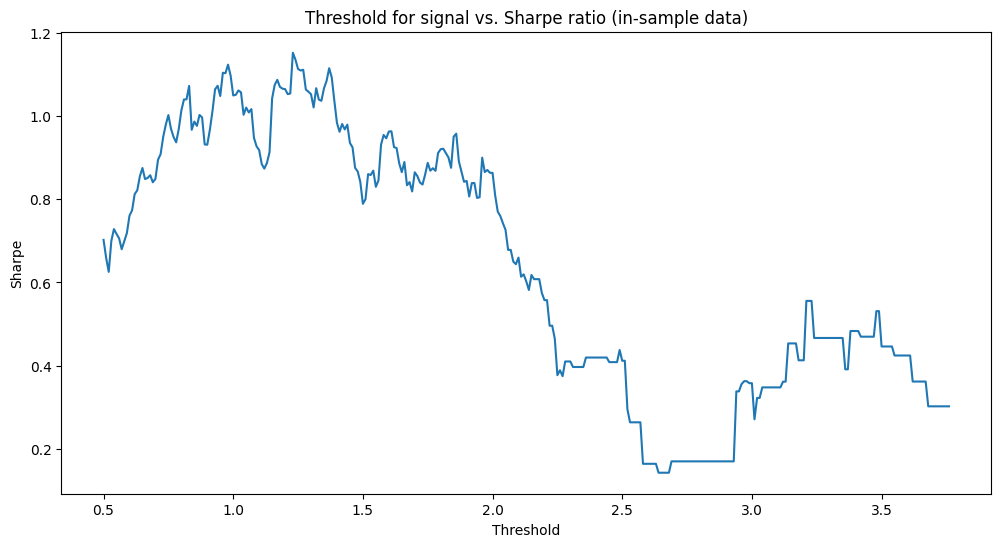

In [49]:
ts = []
sharpes = []

for t in range(50, T_MAX, 1):
    ts.append(t/100)
    signals = list(map(lambda e: signal(e, threshold=t/100), z_scores))
    PnL = signals[:-1] * np.diff(spread) - (np.abs(signals[:-1])*TRANSACTION_PRICE)
    sharpes.append(np.mean(PnL) / np.std(PnL) * np.sqrt(252))



plt.figure(figsize=(12, 6))
plt.plot(ts, sharpes)
plt.title(f"Threshold for signal vs. Sharpe ratio (in-sample data)")
plt.ylabel("Sharpe")
plt.xlabel("Threshold")
plt.plot()

print(ts[np.argmax(sharpes)])

# Out of sample (2026-)

In [50]:
B_test_data = yf.download(B_stock, start=END, end=None)
A_test_data = yf.download(A_stock, start=END, end=None)

if A_test_data[PRICE].values.flatten().mean() > B_test_data[PRICE].values.flatten().mean():
    temp = A_test_data
    A_test_data = B_test_data
    B_test_data = temp

print(len(B_test_data.index), len(A_test_data.index))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

338 338


In [51]:
_, p_value, _ = sm.coint(B_test_data[PRICE].values.flatten(), A_test_data[PRICE].values.flatten())
print(f"Cointegration p-value: {p_value:.10f}")

Cointegration p-value: 0.4131979915


[]

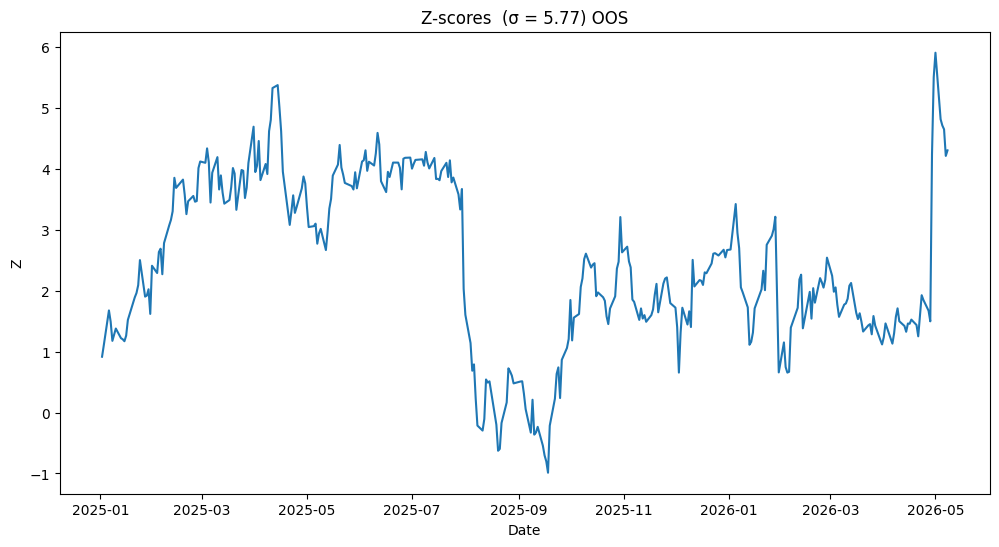

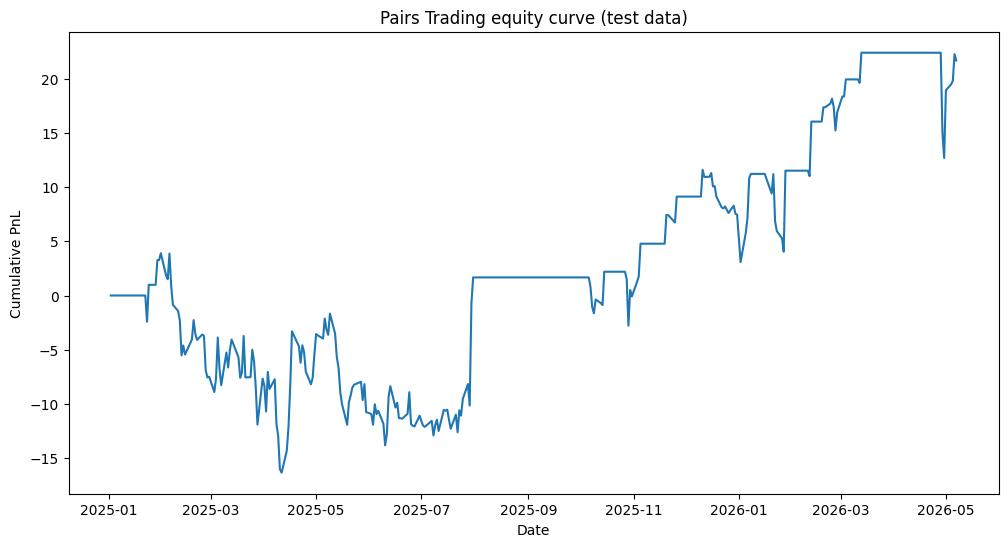

In [52]:
test_time_data = A_test_data.index

test_spread = A_test_data[PRICE].values.flatten() - params[0] * B_test_data[PRICE].values.flatten() - params[1]

test_z_scores = test_spread / sigma

test_signals = list(map(lambda e: signal(e, threshold=THRESHOLD), test_z_scores))

test_PnL = test_signals[:-1] * np.diff(test_spread) - (np.abs(test_signals[:-1])*TRANSACTION_PRICE)

plt.figure(figsize=(12, 6))
plt.plot(test_time_data, test_z_scores, label="Spread")
plt.title(f"Z-scores  (\u03C3 = {round(sigma, 2)}) OOS")
plt.xlabel("Date")
plt.ylabel("Z")
plt.plot()

plt.figure(figsize=(12, 6))
plt.plot(test_time_data[:-1], np.cumsum(test_PnL))
plt.title(f"Pairs Trading equity curve (test data)")
plt.ylabel("Cumulative PnL")
plt.xlabel("Date")
plt.plot()

In [53]:
print(np.mean(test_PnL) / np.std(test_PnL) * np.sqrt(252))

0.6308400393682229


4.26


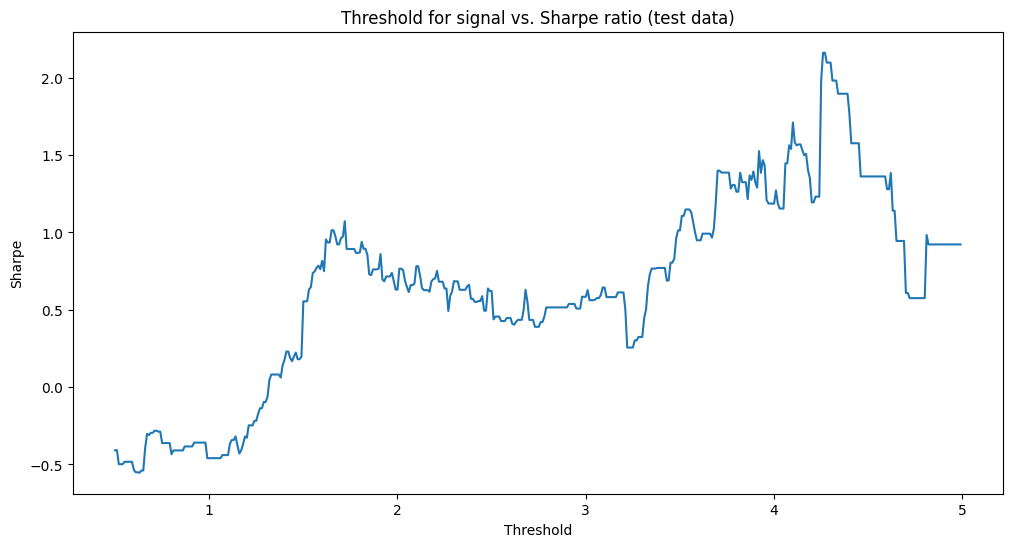

In [54]:
ts = []
sharpes = []

for t in range(50, T_MAX, 1):
    ts.append(t/100)
    test_signals = list(map(lambda e: signal(e, threshold=t/100), test_z_scores))
    test_PnL = test_signals[:-1] * np.diff(test_spread) - (np.abs(test_signals[:-1])*TRANSACTION_PRICE)
    sharpes.append(np.mean(test_PnL) / np.std(test_PnL) * np.sqrt(252))



plt.figure(figsize=(12, 6))
plt.plot(ts, sharpes)
plt.title(f"Threshold for signal vs. Sharpe ratio (test data)")
plt.ylabel("Sharpe")
plt.xlabel("Threshold")
plt.plot()

print(ts[np.argmax(sharpes)])


# All time

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

3106 3106


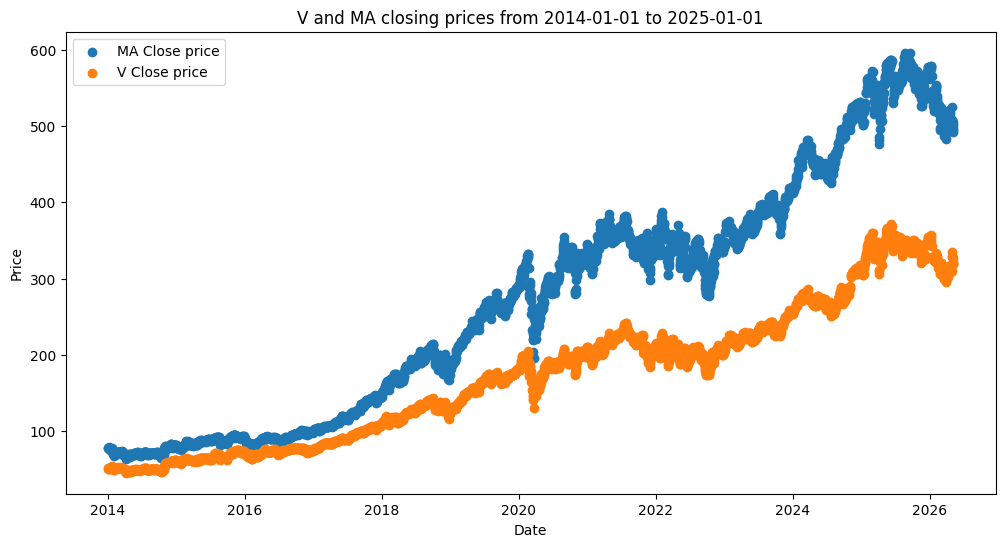

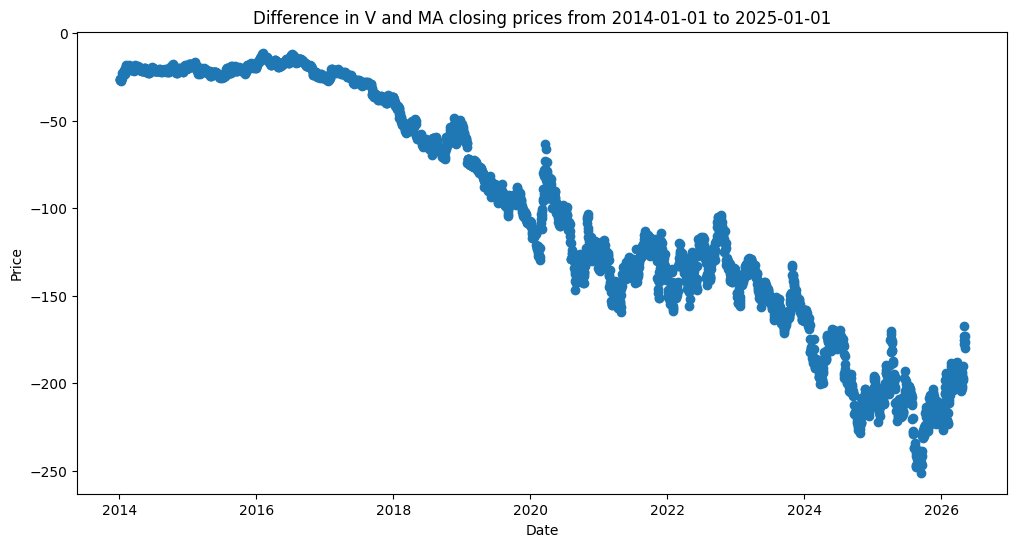

In [55]:
B_data = yf.download(B_stock, start=START, end=None)
A_data = yf.download(A_stock, start=START, end=None)

print(len(B_data.index), len(A_data.index))
time_data = B_data.index

plt.figure(figsize=(12, 6))
plt.scatter(time_data, B_data[PRICE], label=f"{B_stock} {PRICE} price")
plt.scatter(time_data, A_data[PRICE], label=f"{A_stock} {PRICE} price")
plt.title(f"{A_stock} and {B_stock} closing prices from {START} to {END}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(time_data, (A_data[PRICE].values.flatten() - B_data[PRICE].values.flatten()), label="Difference")
plt.title(f"Difference in {A_stock} and {B_stock} closing prices from {START} to {END}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()